# Fake News Detection — A Comparative Study of Text Representations

**Author:** Mainak Jana

## Objective
Compare four ways of turning news text into features for a classifier:

| Representation | Type | Captures |
|---|---|---|
| **CountVectorizer** | Sparse, frequency | Word/bigram counts |
| **TF-IDF** | Sparse, weighted | Counts down-weighted by document frequency |
| **Word2Vec** (mean-pooled) | Dense, 100-d | Distributional word semantics, averaged |
| **Doc2Vec** | Dense, 100-d | A single learned vector per document |

## Experimental design
This is a study of **representations**, so the downstream classifier is held **fixed** —
**Logistic Regression**, tuned over the same grid of `C` values for every representation — and
every representation is evaluated on the **same** train/test split with the **same** metrics.
That way any difference in performance is attributable to the representation, not the model.

> If the classifier changed across representations, the comparison would be confounded and
> wouldn't actually answer the question being asked.

## Dataset
ISOT Fake News dataset (`True.csv` / `Fake.csv`, ~45k articles) from
[Kaggle](https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets).

⚠️ **This dataset has known source leakage** (the real articles are Reuters wire copy with a
tell-tale dateline). We diagnose it, mitigate it, and report honest numbers. See the
"Data leakage" section — this is the most important part of the study.


In [5]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
STOP = set(stopwords.words("english"))
sns.set_style("whitegrid")


## 1. Load the data

In [6]:
# Expects True.csv and Fake.csv in the working directory.
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

fake_df["label"] = 0   # 0 = fake
true_df["label"] = 1   # 1 = real

df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)

# Use title + body as the document text.
df["title"] = df.get("title", "").fillna("")
df["text"]  = df["text"].fillna("")
df["content"] = (df["title"] + " " + df["text"]).str.strip()

print(f"Total articles: {len(df):,}")
print(df["label"].value_counts().rename({0: "fake", 1: "real"}))
df[["title", "subject", "label"]].sample(5, random_state=RANDOM_STATE)


Total articles: 44,898
label
fake    23481
real    21417
Name: count, dtype: int64


,title,subject,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,US_News,0
27917,Trump drops Steve Bannon from National Securit...,politicsNews,1
25007,Puerto Rico expects U.S. to lift Jones Act shi...,politicsNews,1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,News,0
32476,Donald Trump heads for Scotland to reopen a go...,politicsNews,1


## 2. Data leakage — the part that actually matters

The ISOT real articles come from the Reuters wire and almost all begin with a dateline like
`WASHINGTON (Reuters) -`. The fake articles never contain `(Reuters)`. A model can therefore
score ~99% by memorising that single token instead of learning anything about misinformation.

We first **quantify** the leak, then **strip** it (plus the dateline and obvious duplicates),
and run the entire comparison on the cleaned text.

In [7]:
# --- Diagnose the leak ---
reuters_in_real = true_df["text"].str.contains(r"\(Reuters\)", case=False, na=False).mean()
reuters_in_fake = fake_df["text"].str.contains(r"\(Reuters\)", case=False, na=False).mean()
print(f"'(Reuters)' appears in {reuters_in_real:.1%} of REAL articles "
      f"and {reuters_in_fake:.1%} of FAKE articles.")
print("=> a single token nearly separates the classes. This is leakage, not signal.")


'(Reuters)' appears in 99.2% of REAL articles and 0.0% of FAKE articles.
=> a single token nearly separates the classes. This is leakage, not signal.


In [8]:
# --- Mitigate the leak ---
DATELINE = re.compile(r"^.*?\(reuters\)\s*-\s*", flags=re.IGNORECASE)  # 'CITY (Reuters) - '

def strip_source_artifacts(text):
    text = DATELINE.sub("", text)                 # remove leading Reuters dateline
    text = re.sub(r"\(reuters\)", " ", text, flags=re.IGNORECASE)  # any stray mentions
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # URLs (a tell in fake articles)
    return text

df["content"] = df["content"].apply(strip_source_artifacts)

# Drop duplicates and empties that would inflate scores / waste capacity.
before = len(df)
df = df.drop_duplicates(subset="content").reset_index(drop=True)
df = df[df["content"].str.split().str.len() >= 5].reset_index(drop=True)
print(f"Removed {before - len(df):,} duplicate/near-empty rows. Remaining: {len(df):,}")

# Confirm the leak is gone.
print("'(Reuters)' remaining anywhere:",
      df["content"].str.contains(r"\(Reuters\)", case=False).sum())


Removed 5,807 duplicate/near-empty rows. Remaining: 39,091
'(Reuters)' remaining anywhere: 0


## 3. Preprocessing (done once, consistently)

A **single** tokenizer produces the token list for every representation. The sparse models
(Count, TF-IDF) consume the joined string; the embedding models (Word2Vec, Doc2Vec) consume
the token list. Same input, different representation — that's what keeps the comparison fair.

In [9]:
def clean_to_tokens(doc):
    tokens = word_tokenize(doc.lower())
    tokens = [w for w in tokens if w.isalpha() and w not in STOP and len(w) > 2]
    return tokens

df["tokens"] = df["content"].apply(clean_to_tokens)
df["clean_str"] = df["tokens"].apply(" ".join)

# Drop anything that became empty after cleaning.
df = df[df["tokens"].str.len() > 0].reset_index(drop=True)
df[["clean_str", "label"]].head(3)


,clean_str,label
0,donald trump sends embarrassing new year eve m...,0
1,drunk bragging trump staffer started russian c...,0
2,sheriff david clarke becomes internet joke thr...,0


## 4. One train/test split, shared by every representation

In [10]:
idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df["label"])

y_train = df.loc[idx_train, "label"].to_numpy()
y_test  = df.loc[idx_test,  "label"].to_numpy()

tokens_train = df.loc[idx_train, "tokens"].tolist()
tokens_test  = df.loc[idx_test,  "tokens"].tolist()
str_train    = df.loc[idx_train, "clean_str"].tolist()
str_test     = df.loc[idx_test,  "clean_str"].tolist()

print(f"Train: {len(idx_train):,}   Test: {len(idx_test):,}")


Train: 31,272   Test: 7,819


## 5. Evaluation harness

One function trains the **same** tuned Logistic Regression on whatever feature matrix it's
given and records accuracy, precision, recall, F1 and ROC-AUC. Results accumulate in a list
so we can build the final comparison table.

In [11]:
results = []

def evaluate(name, X_tr, X_te, plot=True):
    grid = GridSearchCV(
        LogisticRegression(penalty="l2", solver="liblinear", max_iter=1000),
        param_grid={"C": [0.01, 0.1, 1, 10, 100]},
        cv=5, scoring="f1", n_jobs=-1)
    grid.fit(X_tr, y_train)
    clf = grid.best_estimator_

    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]

    row = {
        "Representation": name,
        "Best C": grid.best_params_["C"],
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob),
    }
    results.append(row)
    print(f"[{name}]  best C={row['Best C']}  "
          f"Acc={row['Accuracy']:.4f}  F1={row['F1']:.4f}  AUC={row['ROC-AUC']:.4f}")
    print(classification_report(y_test, y_pred, target_names=["fake", "real"]))

    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d",
                    cmap="Blues", ax=ax[0],
                    xticklabels=["fake", "real"], yticklabels=["fake", "real"])
        ax[0].set(title=f"{name} — Confusion Matrix",
                  xlabel="Predicted", ylabel="True")
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        ax[1].plot(fpr, tpr, label=f"AUC = {row['ROC-AUC']:.3f}")
        ax[1].plot([0, 1], [0, 1], "--", color="grey")
        ax[1].set(title=f"{name} — ROC", xlabel="FPR", ylabel="TPR")
        ax[1].legend()
        plt.tight_layout(); plt.show()
    return clf


## 6. Representation 1 — CountVectorizer

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\fama_french_regression_project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CountVectorizer]  best C=0.1  Acc=0.9821  F1=0.9836  AUC=0.9961
              precision    recall  f1-score   support

        fake       0.99      0.97      0.98      3581
        real       0.98      0.99      0.98      4238

    accuracy                           0.98      7819
   macro avg       0.98      0.98      0.98      7819
weighted avg       0.98      0.98      0.98      7819



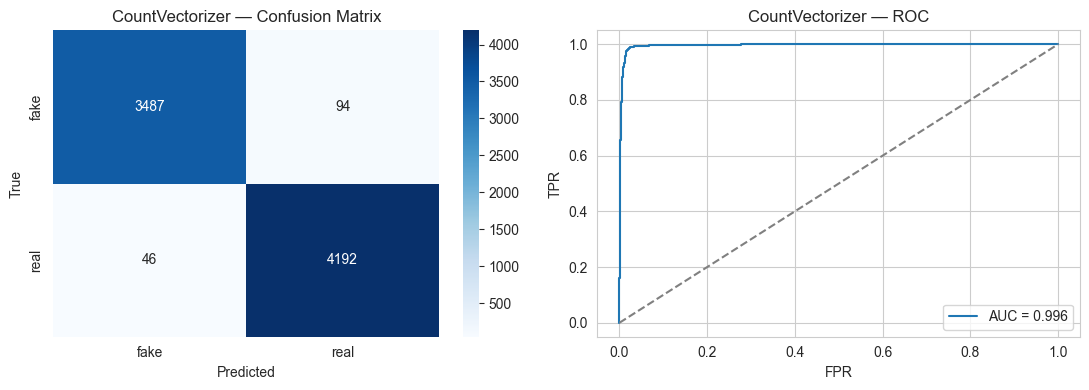

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [12]:
count_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2), lowercase=False)
Xc_train = count_vec.fit_transform(str_train)
Xc_test  = count_vec.transform(str_test)
evaluate("CountVectorizer", Xc_train, Xc_test)


## 7. Representation 2 — TF-IDF

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\fama_french_regression_project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[TF-IDF]  best C=10  Acc=0.9827  F1=0.9842  AUC=0.9985
              precision    recall  f1-score   support

        fake       0.99      0.97      0.98      3581
        real       0.98      0.99      0.98      4238

    accuracy                           0.98      7819
   macro avg       0.98      0.98      0.98      7819
weighted avg       0.98      0.98      0.98      7819



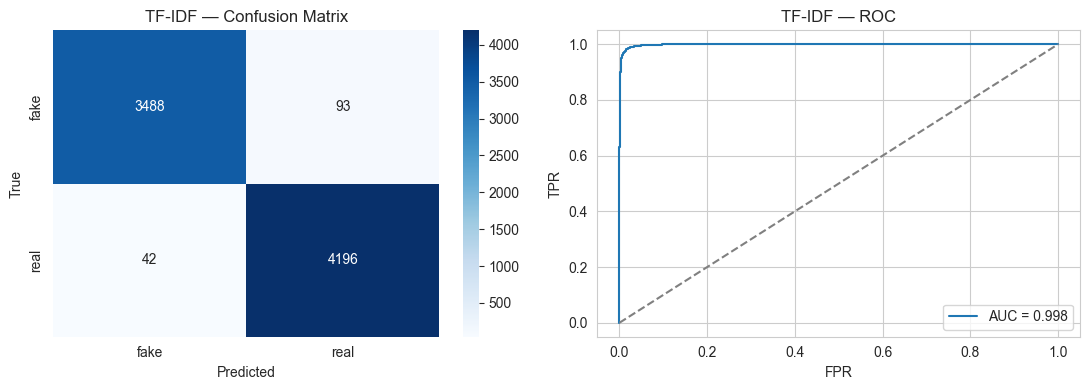

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [13]:
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), lowercase=False)
Xt_train = tfidf_vec.fit_transform(str_train)
Xt_test  = tfidf_vec.transform(str_test)
evaluate("TF-IDF", Xt_train, Xt_test)


## 8. Representation 3 — Word2Vec (mean-pooled)

Word2Vec is trained on the **training tokens only** (no test leakage). Each document is
represented by the **mean** of its word vectors, then standardised before the classifier.

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\fama_french_regression_project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[Word2Vec]  best C=0.1  Acc=0.9616  F1=0.9648  AUC=0.9928
              precision    recall  f1-score   support

        fake       0.96      0.95      0.96      3581
        real       0.96      0.97      0.96      4238

    accuracy                           0.96      7819
   macro avg       0.96      0.96      0.96      7819
weighted avg       0.96      0.96      0.96      7819



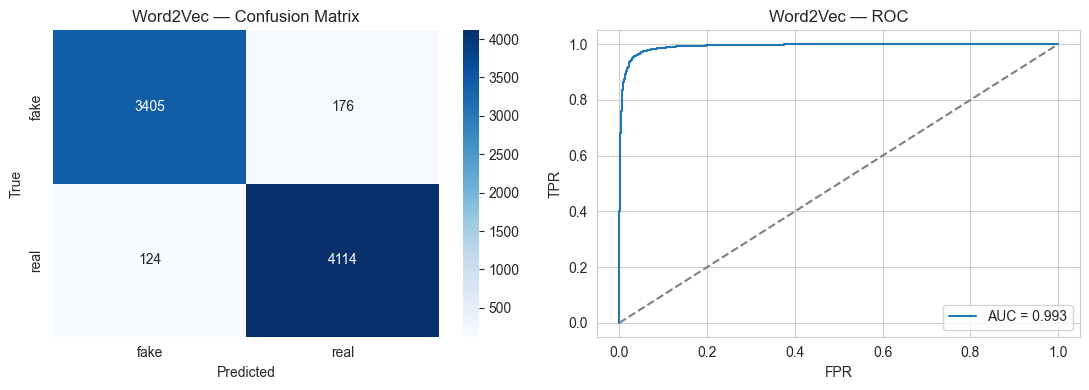

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [14]:
w2v = Word2Vec(sentences=tokens_train, vector_size=100, window=5,
               min_count=2, workers=4, seed=RANDOM_STATE)

def mean_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

Xw_train = np.vstack([mean_vector(t, w2v) for t in tokens_train])
Xw_test  = np.vstack([mean_vector(t, w2v) for t in tokens_test])

scaler = StandardScaler().fit(Xw_train)   # fit on train, apply to both
evaluate("Word2Vec", scaler.transform(Xw_train), scaler.transform(Xw_test))


## 9. Representation 4 — Doc2Vec

Doc2Vec learns one vector per document. We use the **learned** training vectors (`model.dv`)
for the training set and `infer_vector` for unseen test documents. `workers=1` + a fixed seed
keeps training reproducible.

c:\Users\MAINAK\OneDrive\Desktop\pgdba projects\fama_french_regression_project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[Doc2Vec]  best C=0.01  Acc=0.9633  F1=0.9661  AUC=0.9930
              precision    recall  f1-score   support

        fake       0.96      0.96      0.96      3581
        real       0.97      0.96      0.97      4238

    accuracy                           0.96      7819
   macro avg       0.96      0.96      0.96      7819
weighted avg       0.96      0.96      0.96      7819



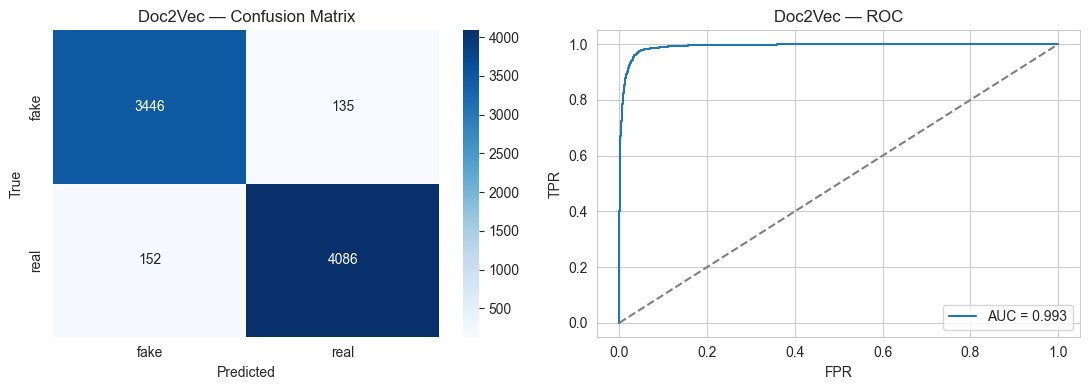

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass

In [15]:
tagged_train = [TaggedDocument(words=t, tags=[i]) for i, t in enumerate(tokens_train)]

d2v = Doc2Vec(vector_size=100, window=5, min_count=2, epochs=40,
              workers=1, seed=RANDOM_STATE)
d2v.build_vocab(tagged_train)
d2v.train(tagged_train, total_examples=d2v.corpus_count, epochs=d2v.epochs)

Xd_train = np.vstack([d2v.dv[i] for i in range(len(tokens_train))])
Xd_test  = np.vstack([d2v.infer_vector(t) for t in tokens_test])

scaler = StandardScaler().fit(Xd_train)
evaluate("Doc2Vec", scaler.transform(Xd_train), scaler.transform(Xd_test))


## 10. Results — side by side

In [16]:
res_df = (pd.DataFrame(results)
          .set_index("Representation")
          .sort_values("F1", ascending=False))
res_df.style.format({c: "{:.4f}" for c in
                     ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]}) \
            .background_gradient(cmap="Greens", subset=["F1", "ROC-AUC"])


,Best C,Accuracy,Precision,Recall,F1,ROC-AUC
Representation,,,,,,
TF-IDF,10.000000,0.9827,0.9783,0.9901,0.9842,0.9985
CountVectorizer,0.100000,0.9821,0.9781,0.9891,0.9836,0.9961
Doc2Vec,0.010000,0.9633,0.9680,0.9641,0.9661,0.9930
Word2Vec,0.100000,0.9616,0.9590,0.9707,0.9648,0.9928


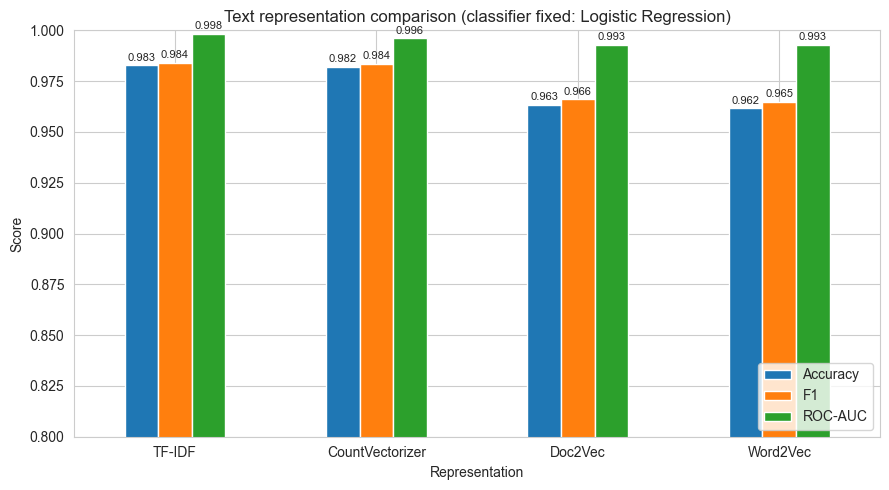

In [17]:
ax = res_df[["Accuracy", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(9, 5), rot=0, ylim=(0.8, 1.0))
ax.set(title="Text representation comparison (classifier fixed: Logistic Regression)",
       ylabel="Score")
ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()


## 11. Conclusions

| Representation | Accuracy | Precision | Recall | F1 | ROC-AUC | Best C |
|---|---|---|---|---|---|---|
| **TF-IDF** | 0.9827 | 0.9783 | 0.9901 | **0.9842** | **0.9985** | 10 |
| **CountVectorizer** | 0.9821 | 0.9781 | 0.9891 | 0.9836 | 0.9961 | 0.1 |
| **Doc2Vec** | 0.9633 | 0.9680 | 0.9641 | 0.9661 | 0.9930 | 0.01 |
| **Word2Vec** | 0.9616 | 0.9590 | 0.9707 | 0.9648 | 0.9928 | 0.1 |

**Sparse n-gram features win.** TF-IDF is the top representation (F1 0.9842, ROC-AUC 0.9985),
narrowly ahead of CountVectorizer. The edge comes from TF-IDF down-weighting common terms and
up-weighting the rare, discriminative ones — small in F1 but clearest in ROC-AUC.

**Sparse beats dense by ~1.8 F1 points.** TF-IDF and CountVectorizer (~0.984) clearly outperform
Doc2Vec and Word2Vec (~0.965). Once the source artifacts are stripped, separating fake from real
here is still largely a matter of *vocabulary and phrasing*, and sparse models preserve the exact
discriminative terms that mean-pooling word vectors washes out.

**Doc2Vec ≈ Word2Vec.** Doc2Vec edges Word2Vec (0.9661 vs 0.9648 F1), but the gap is within noise —
learning a document vector directly is only marginally better than averaging word vectors on this task.

**The regularisation tells a story.** TF-IDF's best `C` is 10 (light regularisation — its weighted
features are trustworthy), while CountVectorizer needs `C` = 0.1 (heavy shrinkage — raw counts are
noisier and higher-variance, so the model must lean on regularisation to avoid overfitting them).

**A note on the errors.** Across all four models recall (for the *real* class) exceeds precision,
so the models lean toward labelling articles *real* — meaning a few fakes slip through as real. For a
misinformation use-case that's the more costly direction, and would motivate tuning the decision
threshold rather than leaving it at 0.5.

### The honest caveat
Even after removing the Reuters leakage, every representation scores 96–98%. This is **not** because
fake-news detection is easy — it's because the real and fake classes in ISOT remain highly separable
on style and vocabulary alone (real = formal wire copy, fake = a different register entirely). These
numbers reflect *dataset separability*, not real-world difficulty.

### Limitations & next steps
- The decisive test of generalisation is to evaluate on a **different** fake-news source; high
  in-dataset scores say little about transfer.
- Mean-pooling is the weakest link in the Word2Vec pipeline — TF-IDF-weighted pooling or pretrained
  GloVe embeddings would be a fairer test of what distributional semantics can do.
- The classifier is fixed to isolate the representation; repeating the table with a linear SVM is a
  cheap robustness check that the TF-IDF > Count > dense ranking holds.